In [1]:
import time
import torch
import random
import math
import os

from glob import glob
from typing import Iterable
import numpy as np
from scipy.io import loadmat
import seaborn as sns
from sklearn.decomposition import PCA

from torch import nn, Tensor, optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
# To avoide meshgrid warning
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [3]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


In [4]:
torch.manual_seed(42)

In [34]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x


#MLP
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        #print("INSIDE")
        sz = x.size()
        #print(x.shape)
        x = x.reshape(-1, self.input_dim)
        #print(x.shape)
        t = t.reshape(-1, self.time_dim).float()
        #print(t.shape)

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)


#ConvNet
class ConvFlow(nn.Module):

    def __init__(self, input_dim: int = 64, hidden_dim: int = 64, time_dim: int = 1):
        super().__init__()

        self.input_dim  = input_dim
        self.hidden_dim = hidden_dim
        # time embedding 
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Conv2d(1 + hidden_dim, hidden_dim, 3, padding=1),
            Swish(),
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1),
            Swish(),
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1),
            Swish(),
            nn.Conv2d(hidden_dim, 1, 3, padding=1)
        )

    def forward(self, x: Tensor, t: Tensor) -> Tensor:

        if x.dim() == 2:
            x = x.view(x.size(0), 1, self.input_dim, self.input_dim)

        B, _, H, W = x.shape

        # time embedding (B, hidden_dim)
        t_emb = self.time_mlp(t)
        t_emb = t_emb.unsqueeze(-1).unsqueeze(-1)      # (B, hidden_dim, 1, 1)
        t_map = t_emb.expand(-1, -1, H, W)             # (B, hidden_dim, H, W)

        # concat time conditioning
        h = torch.cat([x, t_map], dim=1)               # (B, 1+hidden_dim, H, W)
        out = self.net(h)
        
        return out.view(B, -1)


In [31]:
#Basic conv block 
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            Swish(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            Swish(),
        )
    def forward(self, x): return self.block(x)
        
class UNetFlow(nn.Module):
    """U-Net that automatically sets depth based on input_dim."""
    def __init__(self, input_dim: int = 64, base_ch: int = 64, time_dim: int = 1):
        super().__init__()
        self.input_dim = input_dim
        self.base_ch   = base_ch

        # --- time embedding ---
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, base_ch),
            Swish(),
            nn.Linear(base_ch, base_ch)
        )

        # --- Determine depth automatically ---
        # Each pooling halves H and W → stop before size < 2×2
        max_depth = int(math.floor(math.log2(input_dim))) - 1
        # e.g. 64→5, 128→6, 256→7, 512→8

        # --- Build encoder ---
        self.downs, self.pools = nn.ModuleList(), nn.ModuleList()
        in_ch = 1 + base_ch
        for i in range(max_depth):
            out_ch = base_ch * min(2 ** i, 16)  # cap growth
            self.downs.append(ConvBlock(in_ch, out_ch))
            self.pools.append(nn.MaxPool2d(2))
            in_ch = out_ch

        # --- Bottleneck ---
        self.bottleneck = ConvBlock(in_ch, in_ch * 2)

        # --- Decoder (mirror of encoder) ---
        self.ups, self.up_blocks = nn.ModuleList(), nn.ModuleList()
        rev_chs = [block.block[0].out_channels for block in self.downs[::-1]]
        curr_ch = self.bottleneck.block[0].out_channels
        for skip_ch in rev_chs:
            self.ups.append(nn.ConvTranspose2d(curr_ch, skip_ch, 2, stride=2))
            self.up_blocks.append(ConvBlock(skip_ch * 2, skip_ch))
            curr_ch = skip_ch

        self.out_conv = nn.Conv2d(base_ch, 1, 3, padding=1)

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        if x.dim() == 2:
            side = int(x.size(1) ** 0.5)
            x = x.view(x.size(0), 1, side, side)

        B, _, H, W = x.shape

        # time embedding map
        t_emb = self.time_mlp(t).unsqueeze(-1).unsqueeze(-1)
        t_map = t_emb.expand(-1, -1, H, W)
        h = torch.cat([x, t_map], dim=1)

        # encoder
        skips = []
        for down, pool in zip(self.downs, self.pools):
            h = down(h)
            skips.append(h)
            if h.shape[-2] > 1 and h.shape[-1] > 1:
                h = pool(h)

        # bottleneck
        h = self.bottleneck(h)

        # decoder
        for up, block, skip in zip(self.ups, self.up_blocks, reversed(skips)):
            h = up(h)
            if h.shape[-2:] != skip.shape[-2:]:
                h = nn.functional.interpolate(h, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            h = torch.cat([h, skip], dim=1)
            h = block(h)

        out = self.out_conv(h)
        return out.view(B, -1)

In [6]:
class PoissonDataset(Dataset):
    def __init__(self, data_path, normalize=True, n_samples_for_stats=None):
        
        data = loadmat(data_path)
        phi = data["phi_data"].astype("float32")  # (N, 64, 64)
        f   = data["f_data"].astype("float32")

        if normalize:
            u_mean, u_std = phi.mean(), phi.std() + 1e-8
            f_mean, f_std = f.mean(),   f.std() + 1e-8
            phi = (phi - u_mean) / u_std
            f   = (f   - f_mean) / f_std
        
        self.u = torch.from_numpy(phi).contiguous()
        self.f = torch.from_numpy(f).contiguous()
        
    def __len__(self): return self.u.shape[0]

    def __getitem__(self, index):

        return self.u[index], self.f[index]

In [7]:
@torch.no_grad()
def visualize_flow_evolution(model, val_loader, n_steps=10, device='cuda'):
    model.eval()

    u, f = next(iter(val_loader))
    u = u.flatten(start_dim=1).float().to(device)
    f = f.flatten(start_dim=1).float().to(device)

    n_samples = min(4, f.shape[0])       
    dim = f.shape[1]
    H = W = int(dim**0.5)                #
    t_vals = torch.linspace(0, 1, n_steps + 2, device=device)

    fig, axes = plt.subplots(n_samples, len(t_vals), figsize=(2.5*len(t_vals), 2.5*n_samples))
    if n_samples == 1:
        axes = axes.unsqueeze(0)

    for i in range(n_samples):
        x_t = f[i].unsqueeze(0) 

        for j, t in enumerate(t_vals):
            if j == 0:
                x_plot = f[i]
                title = "t=0 (f)"
            elif j == len(t_vals) - 1:
                x_plot = u[i]
                title = "t=1 (u) gt"
            elif j == len(t_vals) -2:
                dt = t_vals[-1] - t_vals[-2]          
                t_last = t_vals[-2]
                t_next = t_vals[-1]
                v_t = model(x_t, t_last.repeat(x_t.size(0), 1))
                x_t = x_t + dt * v_t  
                x_plot = x_t.squeeze(0)
                title = "t=1 (u) pred"
            else:
                # One Euler step: x_{t+dt} = x_t + dt * v(x_t, t)
                dt = t_vals[j] - t_vals[j-1]
                t_mid = (t_vals[j] + t_vals[j-1]) / 2
                v_t = model(x_t, t_mid.repeat(x_t.size(0), 1))
                x_t = x_t + dt * v_t
                x_plot = x_t.squeeze(0)
                title = f"t={t.item():.2f}"

            ax = axes[i, j]
            ax.imshow(x_plot.view(H, W).cpu(), cmap='viridis')
            ax.axis('off')
            if i == 0:
                ax.set_title(title, fontsize=9)

    plt.tight_layout()
    plt.show()


In [8]:
poisson_train = glob("/home/server/sarper/FlowPDE/data/static/poisson/*8*train*")[0]
poisson_val   = glob("/home/server/sarper/FlowPDE/data/static/poisson/*8*val*")[0]
poisson_train_dataset = PoissonDataset(data_path = poisson_train)
poisson_val_dataset   = PoissonDataset(data_path = poisson_val)

In [9]:
train_loader = DataLoader(dataset=poisson_train_dataset, 
                          batch_size=512,
                          shuffle=True)
val_loader = DataLoader(dataset=poisson_val_dataset, 
                          batch_size=512,
                          shuffle=True)

In [10]:
print("Train samples:", len(poisson_train_dataset))
print("Val samples:", len(poisson_val_dataset))

u, f = poisson_train_dataset[0]
print("u shape:", u.shape)
print("f shape:", f.shape)
print("u dtype:", u.dtype)
print("f dtype:", f.dtype)

Train samples: 10000
Val samples: 2000
u shape: torch.Size([8, 8])
f shape: torch.Size([8, 8])
u dtype: torch.float32
f dtype: torch.float32


In [11]:
def describe_tensor(tensor):
    return {
        "min": tensor.min().item(),
        "max": tensor.max().item(),
        "mean": tensor.mean().item(),
        "std": tensor.std().item()
    }

u_stats = describe_tensor(u)
f_stats = describe_tensor(f)
print("u stats:", u_stats)
print("f stats:", f_stats)


u stats: {'min': -6.668114185333252, 'max': 3.06050705909729, 'mean': -0.7370137572288513, 'std': 2.379129409790039}
f stats: {'min': -3.502941131591797, 'max': 6.5280609130859375, 'mean': -2.9802322387695312e-08, 'std': 2.548496961593628}


In [12]:
def dataset_stats(dataset, n_samples=100):
    u_means, f_means = [], []
    for i in range(min(len(dataset), n_samples)):
        u, f = dataset[i]
        u_means.append(u.mean().item())
        f_means.append(f.mean().item())
    print("u mean mean:", sum(u_means)/len(u_means))
    print("f mean mean:", sum(f_means)/len(f_means))

dataset_stats(poisson_train_dataset)


u mean mean: 0.04287302488577552
f mean mean: 1.4295801520347594e-09


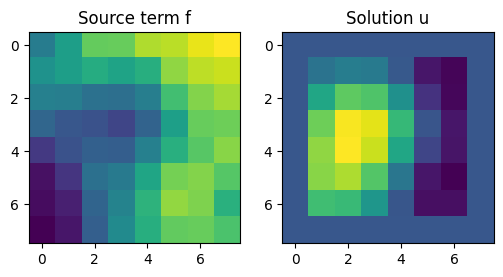

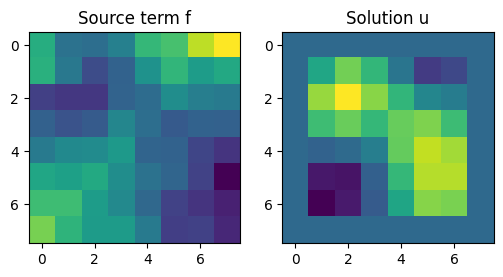

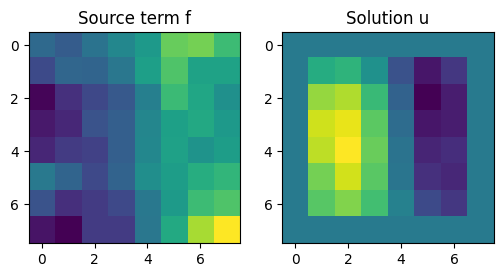

In [13]:
for i in random.sample(range(len(poisson_train_dataset)), 3):
    u, f = poisson_train_dataset[i]
    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    ax[0].imshow(f, cmap='viridis'); ax[0].set_title("Source term f")
    ax[1].imshow(u, cmap='viridis'); ax[1].set_title("Solution u")
    plt.show()

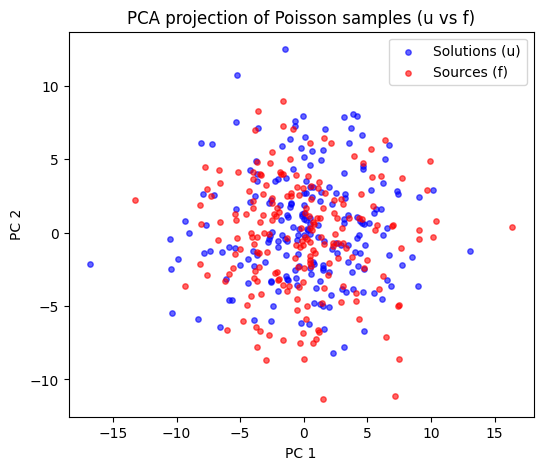

In [14]:
# Collect samples
U, F = [], []
n_samples = min(200, len(poisson_train_dataset))

for i in range(n_samples):
    u, f = poisson_train_dataset[i]
    U.append(u.flatten())
    F.append(f.flatten())

U = np.stack(U)
F = np.stack(F)

# --- Fit PCA on combined data ---
X = np.concatenate([U, F], axis=0)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Split back
u_2d = X_2d[:len(U)]
f_2d = X_2d[len(U):]

# --- Plot together ---
plt.figure(figsize=(6,5))
plt.scatter(u_2d[:,0], u_2d[:,1], s=15, color='blue', alpha=0.6, label='Solutions (u)')
plt.scatter(f_2d[:,0], f_2d[:,1], s=15, color='red', alpha=0.6, label='Sources (f)')
plt.legend()
plt.title("PCA projection of Poisson samples (u vs f)")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.show()


In [15]:
def train(
    model: nn.Module, 
    data_loader: Iterable, 
    optimizer: optim.Optimizer, 
    lr_schedule: optim.lr_scheduler.LRScheduler, 
    device: torch.device,
    epochs: int,
    max_grad_norm: float = 1.0,
    save_interval: int = 20000,
    save_dir: str = "checkpoints"
):
    for epoch in range(epochs):
        start_time = time.time()
        train_loss = train_one_epoch(
            model=model,
            data_loader=data_loader,
            optimizer=optimizer,
            lr_schedule=lr_schedule,
            device=device,
            epoch=epoch,
            max_grad_norm=max_grad_norm,
        )

        lr_schedule.step()
        elapsed = time.time() - start_time
        
        if epoch % 300 == 0 or epoch == epochs - 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"[Epoch {epoch+1:04d}/{epochs}] "
                f"Train Loss: {train_loss:.10f} | "
                f"LR: {current_lr:.2e} | "
                f"Time: {elapsed:.2f}s"
            )

        if (epoch % save_interval == 0 and epoch != 0) or epoch == epochs - 1:
            ckpt_path = os.path.join(save_dir, f"poisson_flowmatching_epoch_{epoch+1}.pt")
            torch.save({
                "epoch": epoch + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": lr_schedule.state_dict(),
                "train_loss": train_loss,
            }, ckpt_path)

            vis_dir = os.path.join(save_dir, "visualizations")
            os.makedirs(vis_dir, exist_ok=True)
            fig_path = os.path.join(vis_dir, f"poisson_flowmatching_epoch_{epoch+1:05d}.png")
            visualize_flow_evolution(model, val_loader, n_steps=8, device=device)
            plt.savefig(fig_path, dpi=200, bbox_inches="tight")
            plt.close()

In [16]:
def train_one_epoch(
    model: nn.Module, 
    data_loader: Iterable, 
    optimizer: optim.Optimizer, 
    lr_schedule: optim.lr_scheduler.LRScheduler, 
    device: torch.device,
    epoch: int,
    max_grad_norm: float = 1.0,
):
    model.train()
    train_loss = 0.0

    for batch_idx, (u, f) in enumerate(data_loader):
        optimizer.zero_grad()

        x_1 = u.flatten(start_dim=1).to(device)
        x_0 = f.flatten(start_dim=1).to(device)
        t = torch.rand((f.shape[0],1), device=device)  

        # print(x_0.shape)
        # print(t.shape)
        # Sample from  path
        x_t = (1 - t) * x_0 + t * x_1
        dx_t = x_1 - x_0
        
        # Compute loss
        loss = ((model(x_t, t) - dx_t) ** 2).mean()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        loss.backward()
        optimizer.step()
        
        train_loss += loss.detach()

    train_loss = train_loss / len(data_loader)
    train_loss = train_loss.item() 
    return train_loss

In [17]:
poisson_train_dataset = PoissonDataset(data_path = poisson_train)
poisson_val_dataset   = PoissonDataset(data_path = poisson_val)

In [18]:
train_loader = DataLoader(
    poisson_train_dataset,
    batch_size=512,                 
    shuffle=True,
    num_workers=4,                            
)
val_loader = DataLoader(
    poisson_val_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=4,
)


In [19]:
input_size = train_loader.dataset.u[0].shape[0]
input_size

8

In [ ]:
flow = MLP(input_dim=input_size**2, 
            hidden_dim=512)
flow = flow.to(device)
optimizer = torch.optim.Adam(flow.parameters(), 
                       lr=3e-5)
epochs = 5
loss_fn = nn.MSELoss()
lr_schedule = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs, 
    eta_min=1e-6
)

In [ ]:
train(
    model=flow,
    data_loader=train_loader,
    optimizer=optimizer,
    lr_schedule=lr_schedule,
    device=device,
    epochs=epochs,
)

In [ ]:
visualize_flow_evolution(flow, val_loader, n_steps=8, device=device)

In [22]:
convFlow = ConvFlow(input_dim=8, hidden_dim=64)
convFlow = convFlow.to(device)
optimizer_conv = torch.optim.Adam(convFlow.parameters(), 
                       lr=3e-5)
epochs = 40001
loss_fn_conv = nn.MSELoss()
lr_schedule_conv = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_conv, 
    T_max=epochs, 
    eta_min=1e-6
)

In [23]:
train(
    model=convFlow,
    data_loader=train_loader,
    optimizer=optimizer_conv,
    lr_schedule=lr_schedule_conv,
    device=device,
    epochs=epochs,
)

[Epoch 0001/40001] Train Loss: 3.0851390362 | LR: 3.00e-05 | Time: 1.16s
[Epoch 0301/40001] Train Loss: 0.4679368436 | LR: 3.00e-05 | Time: 0.25s
[Epoch 0601/40001] Train Loss: 0.3900237083 | LR: 3.00e-05 | Time: 0.26s
[Epoch 0901/40001] Train Loss: 0.3512463272 | LR: 3.00e-05 | Time: 0.22s
[Epoch 1201/40001] Train Loss: 0.3193697035 | LR: 2.99e-05 | Time: 0.23s


KeyboardInterrupt: 

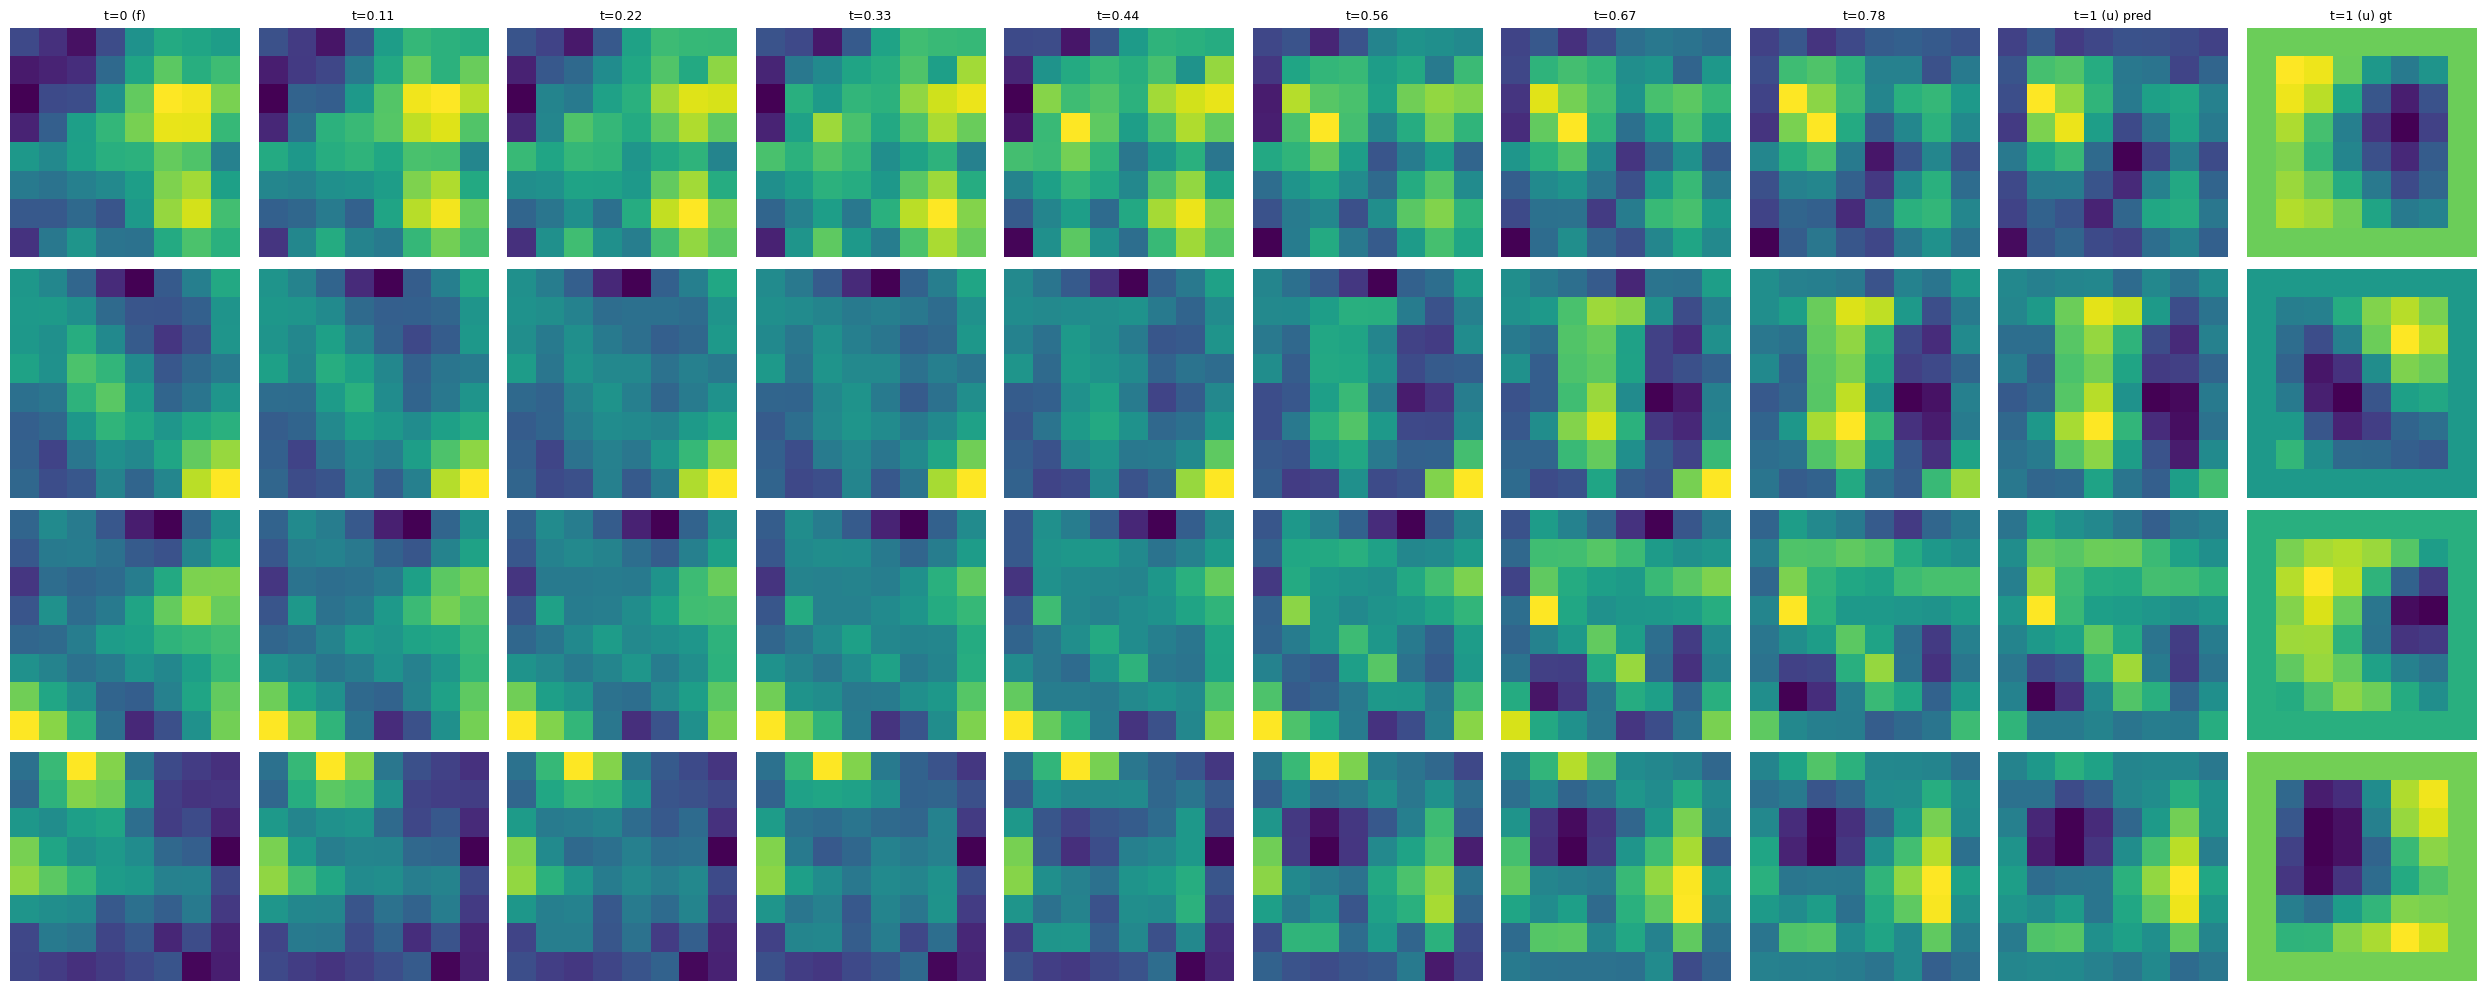

In [24]:
visualize_flow_evolution(convFlow, val_loader, n_steps=8, device=device)

In [35]:
UNetFlow = UNetFlow(input_dim=8)
UNetFlow = UNetFlow.to(device)
optimizer_unet = torch.optim.Adam(UNetFlow.parameters(), 
                       lr=3e-5)
epochs = 40001
loss_fn_unet = nn.MSELoss()
lr_schedule_unet = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_unet, 
    T_max=epochs, 
    eta_min=1e-6
)

In [36]:
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [ ]:
train(
    model=UNetFlow,
    data_loader=train_loader,
    optimizer=optimizer_unet,
    lr_schedule=lr_schedule_unet,
    device=device,
    epochs=epochs,
)

[Epoch 0001/40001] Train Loss: 2.3088271618 | LR: 3.00e-05 | Time: 2.73s
[Epoch 0301/40001] Train Loss: 0.0406906866 | LR: 3.00e-05 | Time: 0.46s
[Epoch 0601/40001] Train Loss: 0.0274029076 | LR: 3.00e-05 | Time: 0.46s
[Epoch 0901/40001] Train Loss: 0.0212349184 | LR: 3.00e-05 | Time: 0.46s
[Epoch 1201/40001] Train Loss: 0.0199900847 | LR: 2.99e-05 | Time: 0.46s
[Epoch 1501/40001] Train Loss: 0.0158217531 | LR: 2.99e-05 | Time: 0.43s
